In [1]:
print("Urrā, viss strādā!")

Urrā, viss strādā!


In [2]:
import pandas as pd
# Šī rinda automātiski paņems datus no pasniedzēja minētā UCI repozitorija!
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00468/online_shoppers_intention.csv"
df = pd.read_csv(url)

print("Dati veiksmīgi ielādēti programmā!")
print(f"Rindu skaits: {df.shape[0]}, Kolonnu skaits: {df.shape[1]}")

Dati veiksmīgi ielādēti programmā!
Rindu skaits: 12330, Kolonnu skaits: 18


In [3]:
# Šī rinda paņems datus no programmas atmiņas un ierakstīs failā uz tava datora
df.to_csv('online_shoppers_intention.csv', index=False)
print("Fails 'online_shoppers_intention.csv' ir veiksmīgi saglabāts tavā mapē!")

Fails 'online_shoppers_intention.csv' ir veiksmīgi saglabāts tavā mapē!


# 1.1. Problēmas apraksts

Mēs esam santehnikas salons, kas pārdod augstas kvalitātes vannasistabas un santehnikas preces. Uzņēmums izveidoja Facebook reklāmas kampaņu akcijas produktam un vēlas saprast, vai klienti pēc reklāmas apskatīšanas veiks pirkumu.

Ja spēsim prognozēt, kuri klienti, visticamāk, iegādāsies akcijas preci, uzņēmums varēs efektīvāk izmantot reklāmas budžetu un palielināt pārdošanas rezultātus.

# 1.2. ML tipa identificēšana

Jā, datu kopa ir kolonna "Revenue", kas parāda, vai klients veica pirkumu vai nē.
Mēs vēlamies prognozēt šo rezultātu katram jaunam apmeklētājam.
ML veids → Supervised Learning
Apakštips → Classification, jo pirkums notika vai nenotika.

# 1.3. Target un Features

Target mainīgais: Revenue (1 = klients veica pirkumu; 0 = klients pameta lapu bez pirkuma)

Features (ievades mainīgie):
Skaitliskās pazīmes: Administrative_Duration, Informational_Duration, ProductRelated_Duration, BounceRates, ExitRates, PageValues
Kategoriskās pazīmes: Month, VisitorType, Weekend

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Vizuālie iestatījumi
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
print("✓ Visas bibliotēkas ielādētas veiksmīgi")

✓ Visas bibliotēkas ielādētas veiksmīgi


In [5]:
# Datu ielāde no UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00468/online_shoppers_intention.csv"
df = pd.read_csv(url)

print(f"Datu kopu forma: {df.shape}")
print(f"Rindu skaits: {df.shape[0]}")
print(f"Kolonnu skaits: {df.shape[1]}")

print("\nPirmās 5 rindas:")
print(df.head())

Datu kopu forma: (12330, 18)
Rindu skaits: 12330
Kolonnu skaits: 18

Pirmās 5 rindas:
   Administrative  Administrative_Duration  Informational  \
0               0                      0.0              0   
1               0                      0.0              0   
2               0                      0.0              0   
3               0                      0.0              0   
4               0                      0.0              0   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                     0.0               1                 0.000000   
1                     0.0               2                64.000000   
2                     0.0               1                 0.000000   
3                     0.0               2                 2.666667   
4                     0.0              10               627.500000   

   BounceRates  ExitRates  PageValues  SpecialDay Month  OperatingSystems  \
0         0.20       0.20         0.0         0.0

In [6]:
# Datu tipi
print("Datu tipi:")
print(df.dtypes)

Datu tipi:
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object


In [7]:
# Statistika par skaitliskajām kolonnām
print("Skaitlisko kolonnu statistika:")
print(df.describe())

Skaitlisko kolonnu statistika:
       Administrative  Administrative_Duration  Informational  \
count    12330.000000             12330.000000   12330.000000   
mean         2.315166                80.818611       0.503569   
std          3.321784               176.779107       1.270156   
min          0.000000                 0.000000       0.000000   
25%          0.000000                 0.000000       0.000000   
50%          1.000000                 7.500000       0.000000   
75%          4.000000                93.256250       0.000000   
max         27.000000              3398.750000      24.000000   

       Informational_Duration  ProductRelated  ProductRelated_Duration  \
count            12330.000000    12330.000000             12330.000000   
mean                34.472398       31.731468              1194.746220   
std                140.749294       44.475503              1913.669288   
min                  0.000000        0.000000                 0.000000   
25%          

In [8]:
# Trūkstošas vērtības
print("Trūkstošas vērtības:")
print(df.isnull().sum())

Trūkstošas vērtības:
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64


In [9]:
# Kategoriskās kolonnas
cat_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()

print(f"Kategoriskās kolonnas: {cat_cols}")

Kategoriskās kolonnas: ['Month', 'VisitorType', 'Weekend', 'Revenue']


In [10]:
# Target mainīgā sadalījums
print("Target mainīgā (Revenue) sadalījums:")

print(df['Revenue'].value_counts())

print(f"Pirkumu īpatsvars: {df['Revenue'].sum() / len(df) * 100:.2f}%")

Target mainīgā (Revenue) sadalījums:
Revenue
False    10422
True      1908
Name: count, dtype: int64
Pirkumu īpatsvars: 15.47%


In [11]:
# Kuras kolonnas satur trūkstošas vērtības?

missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("Kolonnas ar trūkstošām vērtībām:")
print(missing)

# Vizualizācija
if len(missing) > 0:
    plt.figure(figsize=(10, 4))

    missing.plot(kind='barh', color='coral')

    plt.title('Trūkstošās vērtības pa kolonnām')
    plt.xlabel('Trūkstošo vērtību skaits')

    plt.tight_layout()
    plt.show()

else:
    print("✓ Trūkstošo vērtību nav — dati ir tīri!")

Kolonnas ar trūkstošām vērtībām:
Series([], dtype: int64)
✓ Trūkstošo vērtību nav — dati ir tīri!


In [12]:
# Skaitliskām kolonnām — mediāna

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

for col in numeric_cols:
    
    if df[col].isnull().sum() > 0:
        
        median_val = df[col].median()
        
        df[col] = df[col].fillna(median_val)

        print(f"✓ {col}: aizpildīts ar mediānu {median_val:.2f}")


# Kategoriskām kolonnām — moda

cat_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()

for col in cat_cols:
    
    if df[col].isnull().sum() > 0:
        
        mode_val = df[col].mode()[0]

        df[col] = df[col].fillna(mode_val)

        print(f"✓ {col}: aizpildīts ar modu '{mode_val}'")


# Galīgā pārbaude

assert df.isnull().sum().sum() == 0, "Vēl ir trūkstošas vērtības!"

print("\n✓ Visas trūkstošas vērtības apstrādātas.")
print("df.isnull().sum().sum() =", df.isnull().sum().sum())


✓ Visas trūkstošas vērtības apstrādātas.
df.isnull().sum().sum() = 0


# 3.3. Paskaidrojums

Skaitliskajām kolonnām izmantoju mediānu, jo tā labāk apstrādā novirzes un ekstrēmas vērtības nekā vidējā vērtība.

Kategoriskajām kolonnām izmantoju modu (biežāko vērtību), jo tā palīdz saglabāt esošo datu sadalījumu.

Šajā datu kopā trūkstošo vērtību nebija, taču šī metode būs noderīga darbā ar reāliem datiem nākotnē.

In [13]:
# Kādas ir kategoriskās kolonnas?

print("Kategoriskās kolonnas:")

cat_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()

print(cat_cols)

for col in cat_cols:
    
    print(f"\n{col}: {df[col].nunique()} unikālas vērtības")
    
    print(df[col].unique()[:10])  # Parāda pirmās 10 vērtības

Kategoriskās kolonnas:
['Month', 'VisitorType', 'Weekend', 'Revenue']

Month: 10 unikālas vērtības
['Feb' 'Mar' 'May' 'Oct' 'June' 'Jul' 'Aug' 'Nov' 'Sep' 'Dec']

VisitorType: 3 unikālas vērtības
['Returning_Visitor' 'New_Visitor' 'Other']

Weekend: 2 unikālas vērtības
[False  True]

Revenue: 2 unikālas vērtības
[False  True]


In [14]:
# Boolean/binary kolonnas — Label Encoding

df['Weekend'] = df['Weekend'].astype(int)

df['Revenue'] = df['Revenue'].astype(int)

print("✓ Boolean kolonnas konvertētas uz 0/1")

✓ Boolean kolonnas konvertētas uz 0/1


In [15]:
# One-Hot Encoding

df = pd.get_dummies(
    df,
    columns=['Month', 'VisitorType'],
    drop_first=True
)

print(f"✓ One-Hot Encoding pabeigts.")

print(f"Jauns kolonnu skaits: {df.shape[1]}")

print("\nJaunās kolonnas:")

print(df.columns[df.columns.str.contains('Month|VisitorType')])

✓ One-Hot Encoding pabeigts.
Jauns kolonnu skaits: 27

Jaunās kolonnas:
Index(['Month_Dec', 'Month_Feb', 'Month_Jul', 'Month_June', 'Month_Mar',
       'Month_May', 'Month_Nov', 'Month_Oct', 'Month_Sep', 'VisitorType_Other',
       'VisitorType_Returning_Visitor'],
      dtype='object')


In [16]:
# Pārbaude

remaining_cat = df.select_dtypes(include=['object']).columns.tolist()

assert len(remaining_cat) == 0, f"Vēl neapstrādātas: {remaining_cat}"

print("✓ Visas kategoriskās kolonnas kodētas")

print("Atlikušās kategoriskās kolonnas:", len(remaining_cat))


# Visas kolonnas tagad ir skaitliskas vai boolean

print(f"\nKolonnu skaits pēc kodēšanas: {df.shape[1]}")

print("\nDatu tipi:")

print(df.dtypes.value_counts())

✓ Visas kategoriskās kolonnas kodētas
Atlikušās kategoriskās kolonnas: 0

Kolonnu skaits pēc kodēšanas: 27

Datu tipi:
bool       11
int64       9
float64     7
Name: count, dtype: int64


# 4.4. Paskaidrojums

Izmantoju Label Encoding boolean kolonnām (Weekend un Revenue), jo tām ir tikai divas iespējamās vērtības — True vai False.

Izmantoju One-Hot Encoding Month un VisitorType kolonnām, jo tajās ir vairākas kategorijas.

One-Hot Encoding palielina kolonnu skaitu, bet palīdz Machine Learning algoritmiem korekti apstrādāt kategoriskos datus neveidojot nepareizas skaitliskas attiecības starp kategorijām.

In [17]:
# Kādas ir skaitliskās kolonnas

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print(f"Skaitliskās kolonnas ({len(numeric_cols)} pavisam):")

print(numeric_cols[:10])  # Parāda pirmās 10


# Statistika PIRMS normalizācijas

print("\n=== STATISTIKA PIRMS NORMALIZĀCIJAS ===")

print(df[numeric_cols[:6]].describe().round(2))

Skaitliskās kolonnas (16 pavisam):
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']

=== STATISTIKA PIRMS NORMALIZĀCIJAS ===
       Administrative  Administrative_Duration  Informational  \
count        12330.00                 12330.00       12330.00   
mean             2.32                    80.82           0.50   
std              3.32                   176.78           1.27   
min              0.00                     0.00           0.00   
25%              0.00                     0.00           0.00   
50%              1.00                     7.50           0.00   
75%              4.00                    93.26           0.00   
max             27.00                  3398.75          24.00   

       Informational_Duration  ProductRelated  ProductRelated_Duration  
count                12330.00        12330.00                 12330.00  
me

In [18]:
from sklearn.preprocessing import StandardScaler


# Atlasi visas skaitliskās kolonnas, izņemot target

cols_to_scale = [col for col in numeric_cols if col != 'Revenue']


# StandardScaler: (x - mean) / std

scaler = StandardScaler()

df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])


print(f"✓ {len(cols_to_scale)} skaitliskās kolonnas normalizētas")


print("\n=== STATISTIKA PĒC NORMALIZĀCIJAS ===")

print(df[cols_to_scale[:6]].describe().round(2))

✓ 15 skaitliskās kolonnas normalizētas

=== STATISTIKA PĒC NORMALIZĀCIJAS ===
       Administrative  Administrative_Duration  Informational  \
count        12330.00                 12330.00        12330.0   
mean            -0.00                     0.00           -0.0   
std              1.00                     1.00            1.0   
min             -0.70                    -0.46           -0.4   
25%             -0.70                    -0.46           -0.4   
50%             -0.40                    -0.41           -0.4   
75%              0.51                     0.07           -0.4   
max              7.43                    18.77           18.5   

       Informational_Duration  ProductRelated  ProductRelated_Duration  
count                12330.00        12330.00                 12330.00  
mean                    -0.00            0.00                    -0.00  
std                      1.00            1.00                     1.00  
min                     -0.24           -0.7

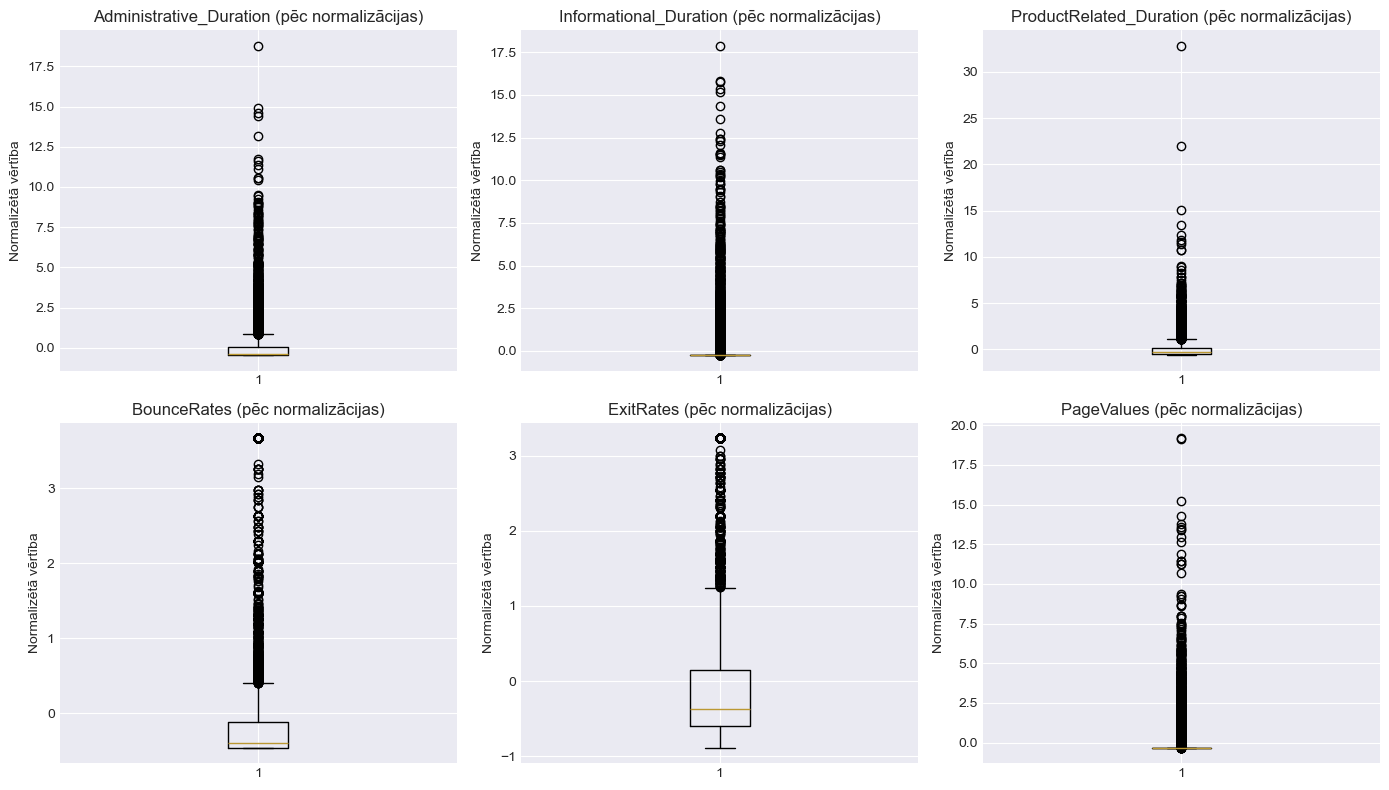

✓ Normalizācijas efekts redzams grafikos — vērtības ir tuvu 0 ar std ≈ 1


In [19]:
# Salīdzinājums pēc normalizācijas

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

axes = axes.flatten()


sample_cols = [
    'Administrative_Duration',
    'Informational_Duration',
    'ProductRelated_Duration',
    'BounceRates',
    'ExitRates',
    'PageValues'
]


for idx, col in enumerate(sample_cols):
    
    if col in df.columns:
        
        axes[idx].boxplot(df[col], vert=True)

        axes[idx].set_title(f'{col} (pēc normalizācijas)')

        axes[idx].set_ylabel('Normalizētā vērtība')


plt.tight_layout()

plt.show()


print("✓ Normalizācijas efekts redzams grafikos — vērtības ir tuvu 0 ar std ≈ 1")

In [20]:
# Jauna iezīme: TotalDuration

df['TotalDuration'] = (
    df['Administrative_Duration']
    + df['Informational_Duration']
    + df['ProductRelated_Duration']
)

print("✓ Jauna iezīme izveidota: TotalDuration")

print(f"Datu kopas forma tagad: {df.shape}")

✓ Jauna iezīme izveidota: TotalDuration
Datu kopas forma tagad: (12330, 28)


# 6.2. Paskaidrojums

Jaunā iezīme "TotalDuration" parāda kopējo laiku, ko lietotājs pavadīja mājaslapā dažādās sadaļās.

Uzņēmumam tas palīdz saprast, cik ieinteresēts ir potenciālais klients. Lietotāji, kuri pavada vairāk laika mājaslapā, biežāk veic pirkumu.

Machine Learning modelim šī iezīme palīdz labāk noteikt atšķirību starp pircējiem un nepircējiem pēc kopējā pavadītā laika. Šie dati lieliski atspoguļo, vai mūsu Facebook reklāmas kampaņa ir nostrādājusi un vai klients gala rezultātā veiks pirkumu.

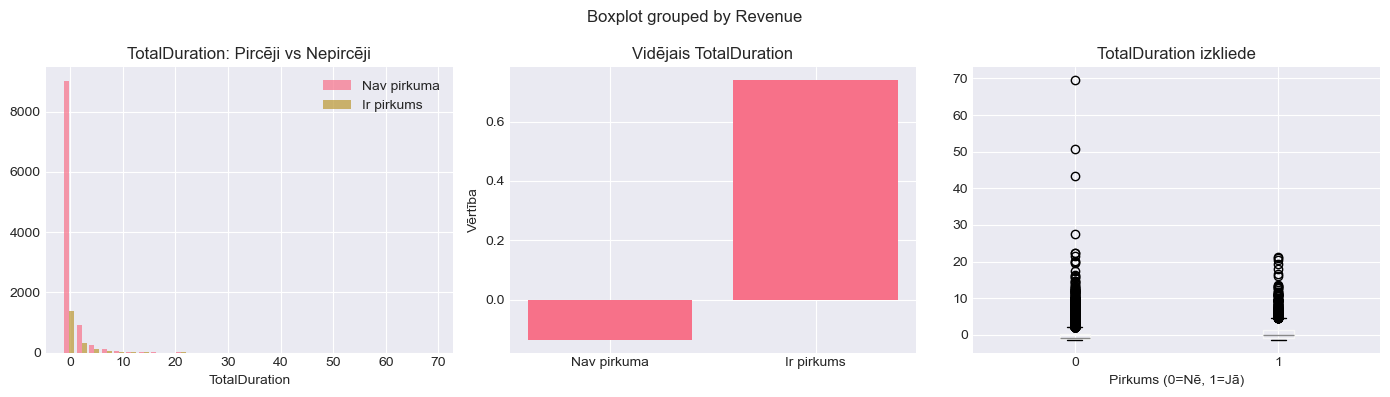

✓ Jaunā iezīme analizēta un vizualizēta


In [21]:
# Salīdzinājums: jaunā iezīme starp pircējiem un nepircējiem

fig, axes = plt.subplots(1, 3, figsize=(14, 4))


# Histogramma

axes[0].hist(
    [
        df[df['Revenue'] == 0]['TotalDuration'],
        df[df['Revenue'] == 1]['TotalDuration']
    ],
    
    label=['Nav pirkuma', 'Ir pirkums'],
    
    bins=30,
    
    alpha=0.7
)

axes[0].set_title('TotalDuration: Pircēji vs Nepircēji')

axes[0].set_xlabel('TotalDuration')

axes[0].legend()


# Vidējās vērtības

axes[1].bar(
    ['Nav pirkuma', 'Ir pirkums'],
    
    [
        df[df['Revenue'] == 0]['TotalDuration'].mean(),
        df[df['Revenue'] == 1]['TotalDuration'].mean()
    ]
)

axes[1].set_title('Vidējais TotalDuration')

axes[1].set_ylabel('Vērtība')


# Boxplot

df.boxplot(
    column='TotalDuration',
    by='Revenue',
    ax=axes[2]
)

axes[2].set_title('TotalDuration izkliede')

axes[2].set_xlabel('Pirkums (0=Nē, 1=Jā)')


plt.tight_layout()

plt.show()


print("✓ Jaunā iezīme analizēta un vizualizēta")

In [32]:
# 7.1. Datu saglabāšana
# Saglabā tīro datu kopu nākamajiem uzdevumiem
output_path = 'shoppers_clean.csv'
df.to_csv(output_path, index=False)

print(f"✓ Datu kopa saglabāta: {output_path}")
print(f"  Rindas: {df.shape[0]}")
print(f"  Kolonnas: {df.shape[1]}")

✓ Datu kopa saglabāta: shoppers_clean.csv
  Rindas: 12330
  Kolonnas: 28


In [23]:
# 7.2. Pārbaude
print("\n=== 7.2. FAILA Nolasīšanas PĀRBAUDE ===")
df_check = pd.read_csv(output_path)
print(f"✓ Fails veiksmīgi nolasīts atpakaļ! Forma: {df_check.shape}")
print("\nPirmās 2 rindas pārbaudei:")
print(df_check.head(2))


=== 7.2. FAILA Nolasīšanas PĀRBAUDE ===
✓ Fails veiksmīgi nolasīts atpakaļ! Forma: (12330, 28)

Pirmās 2 rindas pārbaudei:
   Administrative  Administrative_Duration  Informational  \
0       -0.696993                -0.457191      -0.396478   
1       -0.696993                -0.457191      -0.396478   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0               -0.244931       -0.691003                -0.624348   
1               -0.244931       -0.668518                -0.590903   

   BounceRates  ExitRates  PageValues  SpecialDay  ...  Month_Jul  Month_June  \
0     3.667189   3.229316   -0.317178   -0.308821  ...      False       False   
1    -0.457683   1.171473   -0.317178   -0.308821  ...      False       False   

   Month_Mar  Month_May  Month_Nov  Month_Oct  Month_Sep  VisitorType_Other  \
0      False      False      False      False      False              False   
1      False      False      False      False      False              False   


# 7.3. Rezumējums

## Datu sagatavošanas kopsavilkums

### Identificētās problēmas:
* **Dažādi mērogi:** Datiem bija ļoti atšķirīgi skaitļi (piemēram, laiks sekundēs pret maziem koeficientiem), kas traucētu modelim strādāt objektīvi.
* **Teksta dati:** Mājaslapā mēneši un lietotāju tipi bija pierakstīti ar vārdiem, bet dators saprot tikai skaitļus.

### Veiktās darbības:
1. **Definējām mērķi:** Noteicām, ka šis ir klasifikācijas uzdevums, kur mērķis (`Revenue`) ir uzminēt – klients nopirks santehniku vai nē.
2. **Sagatavojām drošību:** Izveidojām kodu, kas automātiski aizpildītu tukšumus datos, ja tādi parādītos.
3. **Pārvērtām tekstus:** Visas kolonnas ar vārdiem un True/False vērtībām pārveidojām par skaitļiem (0 un 1).
4. **Normalizējām skaitļus:** Izlīdzinājām visas skaitliskās kolonnas, lai tās būtu vienādā mērogā (vidējā vērtība ir 0, standartnovirze ir 1).
5. **Izveidojām jaunu iezīmi:** Pievienojām kolonu `TotalDuration` (kopējais laiks lapā), lai modelis labāk redzētu klienta interesi.

### Rezultāts:
Dati ir veiksmīgi sagatavoti un saglabāti failā `shoppers_clean.csv`. Kolonnu skaits ir pieaudzis no 18 uz 28, jo mēneši un klientu tipi tika sadalīti atsevišķos rādītājos. Fails ir pilnībā gatavs tam, lai nākamajā solī mēs varētu būvēt mašīnmācīšanās modeli.

In [33]:
# 8.1. Ielādē tīro datu kopu un definē X, y
df = pd.read_csv('shoppers_clean.csv')

# Target mainīgais — vai klients veica pirkumu (ko gribam prognozēt)
y = df['Revenue']

# Features — visas pārējās kolonnas (pēc kurām modelis minēs)
X = df.drop('Revenue', axis=1)

print("=== 8.1. DATU IELĀDE UN DEFINĒŠANA ===")
print(f"Features (pazīmju) skaits: {X.shape[1]}")
print(f"Target (mērķa) sadalījums:\n{y.value_counts()}")
print(f"Pirkumu īpatsvars visos datos: {y.mean():.1%}")

=== 8.1. DATU IELĀDE UN DEFINĒŠANA ===
Features (pazīmju) skaits: 27
Target (mērķa) sadalījums:
Revenue
0    10422
1     1908
Name: count, dtype: int64
Pirkumu īpatsvars visos datos: 15.5%


In [25]:
# 8.2. Sadali datos treniņa un testa kopās
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\n=== 8.2. DATU SADALĪŠANA ===")
print(f"Treniņa kopa: {X_train.shape[0]} rindas (80%)")
print(f"Testa kopa: {X_test.shape[0]} rindas (20%)")
print(f"\nTarget sadalījums treniņa kopā (procentos):\n{y_train.value_counts(normalize=True).round(3) * 100}")


=== 8.2. DATU SADALĪŠANA ===
Treniņa kopa: 9864 rindas (80%)
Testa kopa: 2466 rindas (20%)

Target sadalījums treniņa kopā (procentos):
Revenue
0    84.5
1    15.5
Name: proportion, dtype: float64


# 8.3. Paskaidrojums par datu sadalīšanu

Es izvēlējos sadalīt datus proporcijā 80/20 un izmantot `stratify=y` parametru šādu iemeslu dēļ:

1. Tas ir mašīnmācīšanās standarts. Lielākā daļa datu (80%) ir nepieciešama, lai modelis spētu labāk saskatīt sakarības starp pircējiem (piemēram, to pavadīto laiku lapā). Atlikušie 20% tiek paturēti noslēpumā — testa kopa, lai objektīvi pārbaudītu, cik labi modelis spēs prognozēt pirkumus pilnīgi jauniem klientiem.
2. **Kāpēc kritiski svarīgs ir parametrs `stratify=y`?**
   Mūsu santehnikas salona datos pirkumu ir salīdzinoši maz pirkumu — tikai aptuveni 15.5% (dati ir nebalansēti). Ja mēs sadalītu datus nejauši, pastāvētu risks, ka testa kopā nejauši būtu tikai tie klienti, kuri neko nenopērk, un modelis rādītu nekorektu informāciju. `stratify=y` garantē, ka gan treniņa, gan testa kopā tiks saglabāta precīzi viena un tā pati proporcija: ~15.5% pircēju un ~84.5% nepircēju.

In [26]:
# 9.1. Decision Tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Izveido un uztrenē modeli
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train)

# Prognozes uz testa kopas
dt_pred = dt_model.predict(X_test)

print("=== Decision Tree rezultāti ===")
print(classification_report(y_test, dt_pred))

=== Decision Tree rezultāti ===
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      2084
           1       0.73      0.56      0.63       382

    accuracy                           0.90      2466
   macro avg       0.82      0.76      0.79      2466
weighted avg       0.89      0.90      0.89      2466



In [27]:
# 9.2. Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("=== Random Forest rezultāti ===")
print(classification_report(y_test, rf_pred))

=== Random Forest rezultāti ===
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      2084
           1       0.76      0.55      0.64       382

    accuracy                           0.90      2466
   macro avg       0.84      0.76      0.79      2466
weighted avg       0.90      0.90      0.90      2466



In [28]:
# 9.3. Logistic Regression
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

print("=== Logistic Regression rezultāti ===")
print(classification_report(y_test, lr_pred))

=== Logistic Regression rezultāti ===
              precision    recall  f1-score   support

           0       0.89      0.98      0.93      2084
           1       0.75      0.36      0.48       382

    accuracy                           0.88      2466
   macro avg       0.82      0.67      0.71      2466
weighted avg       0.87      0.88      0.86      2466



In [29]:
#10.1. F1 score salīdzinājums
from sklearn.metrics import f1_score

dt_f1 = f1_score(y_test, dt_pred)
rf_f1 = f1_score(y_test, rf_pred)
lr_f1 = f1_score(y_test, lr_pred)

results = pd.DataFrame({
    'Modelis': ['Decision Tree', 'Random Forest', 'Logistic Regression'],
    'F1 Score': [dt_f1, rf_f1, lr_f1]
})

print(results.to_string(index=False))

            Modelis  F1 Score
      Decision Tree  0.632201
      Random Forest  0.635258
Logistic Regression  0.482270


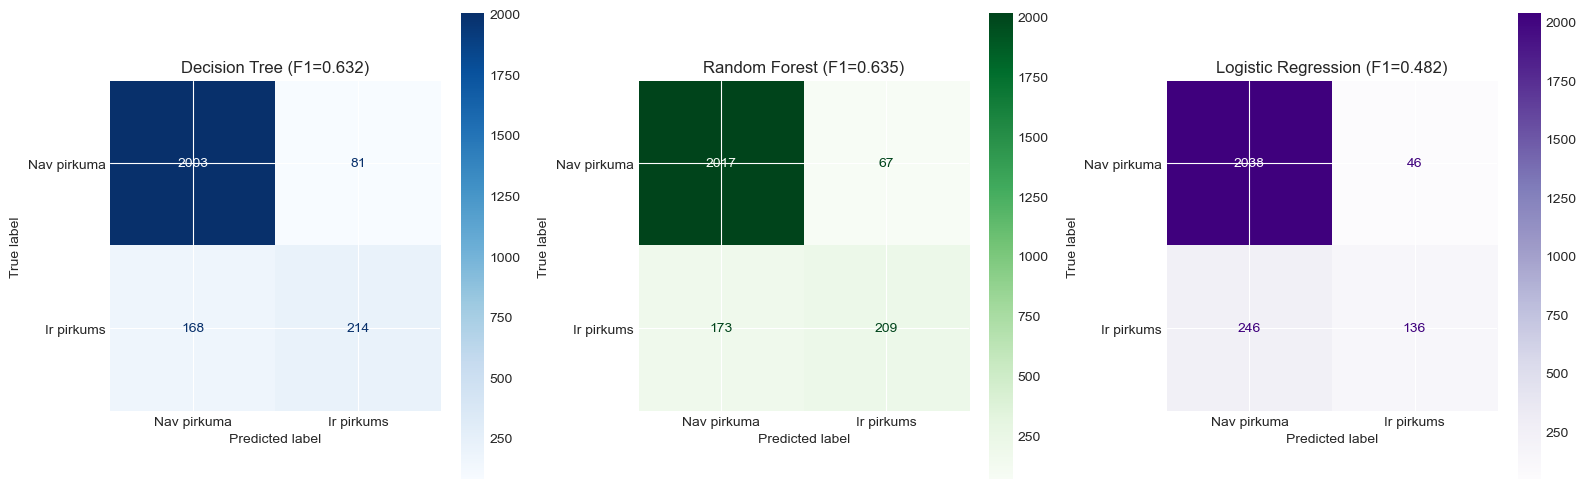

In [30]:
# 10.2. Confusion matrices blakus
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, dt_pred,
    display_labels=['Nav pirkuma', 'Ir pirkums'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title(f'Decision Tree (F1={dt_f1:.3f})')

ConfusionMatrixDisplay.from_predictions(
    y_test, rf_pred,
    display_labels=['Nav pirkuma', 'Ir pirkums'],
    cmap='Greens', ax=axes[1]
)
axes[1].set_title(f'Random Forest (F1={rf_f1:.3f})')

ConfusionMatrixDisplay.from_predictions(
    y_test, lr_pred,
    display_labels=['Nav pirkuma', 'Ir pirkums'],
    cmap='Purples', ax=axes[2]
)
axes[2].set_title(f'Logistic Regression (F1={lr_f1:.3f})')

plt.tight_layout()
plt.show()

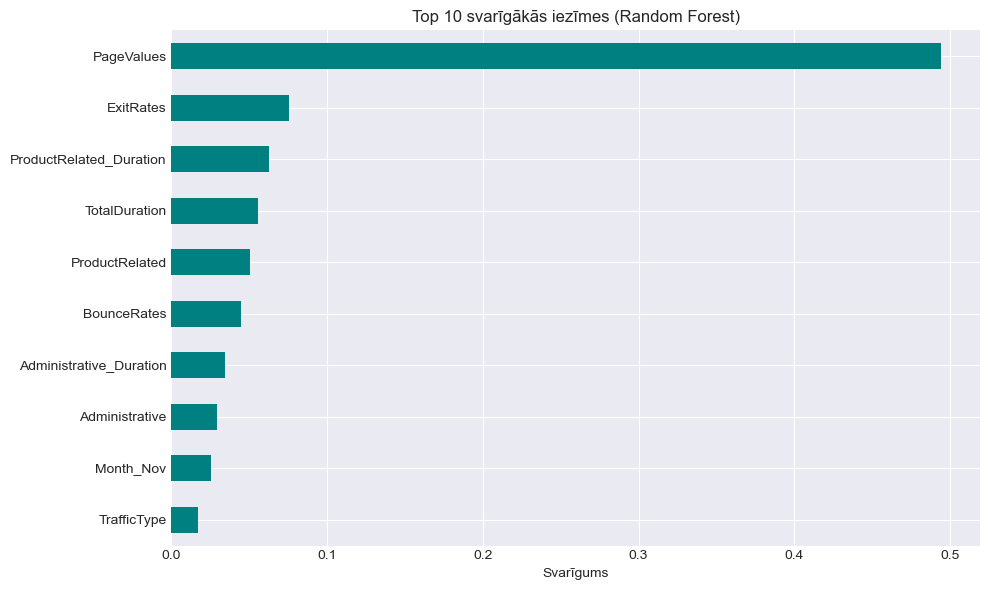

In [31]:
# 10.3. Feature importance
# Kuras iezīmes visvairāk ietekmē prognozi?
importances = rf_model.feature_importances_
feature_names = X.columns
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.head(10).plot(kind='barh', color='teal')
plt.title('Top 10 svarīgākās iezīmes (Random Forest)')
plt.xlabel('Svarīgums')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 10.4. Secinājumi

Salīdzinot visus trīs modeļus, Random Forest modelis ir labāks, jo tas ļauj daudz precīzāk uztvert sarežģītas un nelineāras sakarības datos, kamēr loģistiskā regresija mēģina visu vienkāršoti novilkt kā taisnu līniju.

### Kāpēc F1 Score ir piemērotāks rādītājs nekā Accuracy (precizitāte)?
Šajā uzdevumā dati ir stipri nebalansēti.Ja mēs izmantotu *Accuracy*, modelis varētu vienkārši visiem klientiem pēc kārtas minēt "nepirks" un sasniegt augstu precizitāti (ap 85%), bet tas uzņēmumam nedotu nekādu labumu, jo mēs neatrastu nevienu pircēju. **F1 Score** ir daudz piemērotāks, jo tas meklē līdzsvaru starp to, lai modelis nepalaistu garām reālos pircējus un tajā pašā laikā nesāktu par pircējiem saukt tos, kuri nemaz netaisās iepirkties.

### Kuras iezīmes visvairāk ietekmē prognozes un vai tas ir loģiski?
Skatoties pēc grafika, pati svarīgākā iezīme ar milzīgu pārsvaru ir **PageValues** (lapas vērtība no Google Analytics), kam seko **ExitRates** (pamešanas koeficients) un mūsu pašu izveidotā jaunā iezīme **TotalDuration** (kopējais laiks lapā). No biznesa viedokļa tas ir pilnībā loģiski. Ja klients apmeklē lapas, kurām sistēma jau vēsturiski ir piešķīrusi augstu finansiālu vērtību (piemēram, iepirkumu grozs vai pasūtījuma noformēšana), un ja viņš pavada daudz laika mājaslapā, lasot aprakstus, tas skaidri norāda uz viņa nopietno interesi un gatavību pirkt mūsu preces.